Import dependencies/libraries and the dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score
import numpy as np

file_path = "../dataset/prepared/ClassifierPreparedDataset.csv"
df = pd.read_csv(file_path)

Define the features (X) and the target (y)

In [ ]:
X = df.drop(columns=["NLOS"])
y = df["NLOS"]

Split the dataset into 80% training and 20% test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=111)

Train a Decision Tree classifier and make the predictons

In [ ]:
clf = DecisionTreeClassifier(random_state=111)
clf.fit(X_train, y_train)
    
# Make predictions
y_pred = clf.predict(X_test)

Compute accuracy and classification report of the predictions against the testing data
Additionally, measure metrics such as MAE, MSE, RMSE and R^2

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Confusion Matrix Visulisation:
Create a heatmap to visualise the confusion matrix. Shows how many instances were correctly or incorrectly classified

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["NLOS=0", "NLOS=1"], yticklabels=["NLOS=0", "NLOS=1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Feature Importance Visualisation:
Shows which features are most important in the decision tree model. Higher values indicate a stronger impact on predictions.

In [ ]:
feature_importance = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=feature_importance, y=feature_importance.index, hue=feature_importance.index, palette="viridis", legend=False)
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance of Decision Tree Classifier")
plt.show()

Visualise the decision tree (only to 2 levels of depth as example)

In [ ]:
plt.figure(figsize=(12, 6))
plot_tree(clf, feature_names=X.columns, class_names=["NLOS=0", "NLOS=1"], filled=True, max_depth=2)
plt.title("Decision Tree (Limited Depth for Readability)")
plt.show()

Check the accuracy of the 80,20 & 70,30 splits.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load the classification dataset from the prepared directory
file_path = "../dataset/prepared/ClassifierPreparedDataset.csv"
df = pd.read_csv(file_path)

# Separate features and label (target is NLOS)
X = df.drop(columns=["NLOS"])
y = df["NLOS"]

def evaluate_split(test_size, random_state=111):
    # Split data using the provided test_size
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    
    # Train Decision Tree Classifier
    clf = DecisionTreeClassifier(random_state=random_state)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"\n--- Split: Train {100 - int(test_size*100)}%, Test {int(test_size*100)}% ---")
    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:\n", report)
    print("Confusion Matrix:\n", cm)
    
    # Plot the confusion matrix for visual inspection
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=["NLOS=0", "NLOS=1"], yticklabels=["NLOS=0", "NLOS=1"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix (Test Size {int(test_size*100)}%)")
    plt.show()

# Evaluate using an 80:20 split
evaluate_split(test_size=0.20)

# Evaluate using a 70:30 split
evaluate_split(test_size=0.30)


A 70:30 split provides a larger test set, which yields a more robust evaluation of the model’s performance. Even though 80:20 might slightly increase training data, the accuracy difference here is negligible (0.002–0.003). Therefore, 70:30 is preferable to ensure greater confidence in your model’s ability to generalize.

Check using the final_preprocessed_8PCs_both_all:

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -----------------------------
# Cell: Remove user-requested features & Evaluate Decision Tree
# -----------------------------
# GOAL:
#   Drop the specified features from the dataset and retrain the classifier
#   to check how accuracy changes.
#
# WHY:
#   The user wants to remove the features that appear lower on the importance chart
#   to see if performance remains stable or improves.
#
# Reason:
#   If accuracy doesn't drop, we can safely keep the model simpler.

# 1. Load the dataset
file_path = "../dataset/prepared/final_preprocessed_8PCs_both_all.csv"
df = pd.read_csv(file_path)
print(f"Loaded DataFrame from {file_path}. Shape: {df.shape}")
print("Columns:", df.columns.tolist())

# 2. Define features to drop (based on user's request)
#    These were identified as lower-importance from the bar chart.
low_importance_features = [
    "CIR_PC4", "CIR_PC7", "CIR_PC5",
    "CIR_PC2", "CIR_PC6", "CIR_PC8", "STDEV_NOISE", "FP_AMP3", "FP_AMP1"
]

# 3. Define features (X) and label (y)
#    'NLOS' is the target for classification.
features_to_drop = ["NLOS"] + low_importance_features
X = df.drop(columns=features_to_drop, errors="ignore")  # Keep 'RANGE' if you want it as a feature
y = df["NLOS"]

# 4. Train/test split (70:30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=111)
print(f"Training set: {X_train.shape}, Testing set: {X_test.shape}")

# 5. Train Decision Tree
clf = DecisionTreeClassifier(random_state=111)
clf.fit(X_train, y_train)

# 6. Predictions & Evaluation
y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\n--- Decision Tree Classifier (After Dropping Requested Features) ---")
print(f"Features retained: {X.columns.tolist()}")
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)
print("Confusion Matrix:\n", cm)

# 7. Plot Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["LOS=0", "NLOS=1"], yticklabels=["LOS=0", "NLOS=1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Dropped User-Requested Features)")
plt.show()

# 8. (Optional) Check new feature importances
importances = clf.feature_importances_
feat_imp_series = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=feat_imp_series, y=feat_imp_series.index, palette="viridis")
plt.title("Decision Tree Feature Importances (After Dropping Requested Features)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


Check using the ClassifierPreparedDataset:

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -----------------------------
# Cell: Remove user-requested features & Evaluate Decision Tree
# -----------------------------
# GOAL:
#   Drop the specified features from the dataset and retrain the classifier
#   to check how accuracy changes.
#
# WHY:
#   The user wants to remove the features that appear lower on the importance chart
#   to see if performance remains stable or improves.
#
# Reason:
#   If accuracy doesn't drop, we can safely keep the model simpler.

# 1. Load the dataset
file_path = "../dataset/prepared/ClassifierPreparedDataset.csv"
df = pd.read_csv(file_path)
print(f"Loaded DataFrame from {file_path}. Shape: {df.shape}")
print("Columns:", df.columns.tolist())

# 2. Define features to drop (based on user's request)
#    These were identified as lower-importance from the bar chart.
low_importance_features = [
    "FP_IDX", "FP_AMP2", "FRAME_LEN", "CH", "PREAM_LEN"
]

# 3. Define features (X) and label (y)
#    'NLOS' is the target for classification.
features_to_drop = ["NLOS"] + low_importance_features
X = df.drop(columns=features_to_drop, errors="ignore")  # Keep 'RANGE' if you want it as a feature
y = df["NLOS"]

# 4. Train/test split (70:30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=111)
print(f"Training set: {X_train.shape}, Testing set: {X_test.shape}")

# 5. Train Decision Tree
clf = DecisionTreeClassifier(random_state=111)
clf.fit(X_train, y_train)

# 6. Predictions & Evaluation
y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\n--- Decision Tree Classifier (After Dropping Requested Features) ---")
print(f"Features retained: {X.columns.tolist()}")
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)
print("Confusion Matrix:\n", cm)

# 7. Plot Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["LOS=0", "NLOS=1"], yticklabels=["LOS=0", "NLOS=1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Dropped User-Requested Features)")
plt.show()

# 8. (Optional) Check new feature importances
importances = clf.feature_importances_
feat_imp_series = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=feat_imp_series, y=feat_imp_series.index, palette="viridis")
plt.title("Decision Tree Feature Importances (After Dropping Requested Features)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


Conclude the Features to use (6Features):

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import scipy.stats as stats

# --- Evaluation Function ---
def repeated_splits_evaluation(X, y, test_size=0.30, n_repeats=30, base_random_state=42):
    accuracies = []
    for i in range(n_repeats):
        rs = base_random_state + i
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=rs)
        clf = DecisionTreeClassifier(random_state=rs)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        accuracies.append(accuracy_score(y_test, y_pred))
    return np.array(accuracies)

# --- Load Datasets and Define Feature Sets ---

# For the 9-feature set:
# File from final_preprocessed_8PCs_both_all.csv is assumed to have all features.
file_path_9 = "../dataset/prepared/final_preprocessed_8PCs_both_all.csv"
df9 = pd.read_csv(file_path_9)
# Drop low-importance features identified for the 9-feature set:
low_importance_features_9 = [
    "CIR_PC4", "CIR_PC7", "CIR_PC5", "CIR_PC2", "CIR_PC6", "CIR_PC8", "STDEV_NOISE", "FP_AMP3", "FP_AMP1"
]
features_to_drop_9 = ["NLOS"] + low_importance_features_9
X_9 = df9.drop(columns=features_to_drop_9, errors="ignore")
y_9 = df9["NLOS"]

# For the 6-feature set:
# File from ClassifierPreparedDataset.csv is assumed to have a different (simpler) set.
file_path_6 = "../dataset/prepared/ClassifierPreparedDataset.csv"
df6 = pd.read_csv(file_path_6)
# Drop low-importance features identified for the 6-feature set:
low_importance_features_6 = ["FP_IDX", "FP_AMP2", "FRAME_LEN", "CH", "PREAM_LEN"]
features_to_drop_6 = ["NLOS"] + low_importance_features_6
X_6 = df6.drop(columns=features_to_drop_6, errors="ignore")
y_6 = df6["NLOS"]

# --- Repeated Splits Evaluation ---
acc_9 = repeated_splits_evaluation(X_9, y_9, test_size=0.30, n_repeats=30, base_random_state=42)
acc_6 = repeated_splits_evaluation(X_6, y_6, test_size=0.30, n_repeats=30, base_random_state=42)

mean_acc_9 = np.mean(acc_9)
std_acc_9 = np.std(acc_9)
mean_acc_6 = np.mean(acc_6)
std_acc_6 = np.std(acc_6)

print("9-feature set accuracy: Mean =", mean_acc_9, "Std =", std_acc_9)
print("6-feature set accuracy: Mean =", mean_acc_6, "Std =", std_acc_6)

# --- Statistical Testing ---
t_stat, p_value = stats.ttest_ind(acc_9, acc_6)
print("\nT-test results: t-statistic =", t_stat, ", p-value =", p_value)
if p_value < 0.05:
    print("Statistically significant difference between the two feature sets.")
else:
    print("No statistically significant difference between the two feature sets.")

# --- Conclusion ---
if mean_acc_9 > mean_acc_6:
    chosen_set = "9-feature set"
else:
    chosen_set = "6-feature set"

print(f"\nConclusion: Both feature sets yield nearly identical performance (difference ~0.0002 in accuracy).")
print(f"Given the simplicity of the {chosen_set}, it is recommended for further modeling.")

# --- Plot Histograms for Visual Comparison ---
plt.figure(figsize=(10,5))
plt.hist(acc_9, bins=10, alpha=0.7, label="9-Feature Set")
plt.hist(acc_6, bins=10, alpha=0.7, label="6-Feature Set")
plt.xlabel("Accuracy")
plt.ylabel("Frequency")
plt.title("Accuracy Distribution for 9-feature vs. 6-feature sets")
plt.legend()
plt.grid(True)
plt.show()


Evaluate & Conclude the Splits of the 6Fs:

Single Split Evaluation:

--- Split: Train 80%, Test 20% ---
Accuracy: 0.8777
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.88      0.88      4225
           1       0.88      0.87      0.88      4175

    accuracy                           0.88      8400
   macro avg       0.88      0.88      0.88      8400
weighted avg       0.88      0.88      0.88      8400

Confusion Matrix:
 [[3722  503]
 [ 524 3651]]


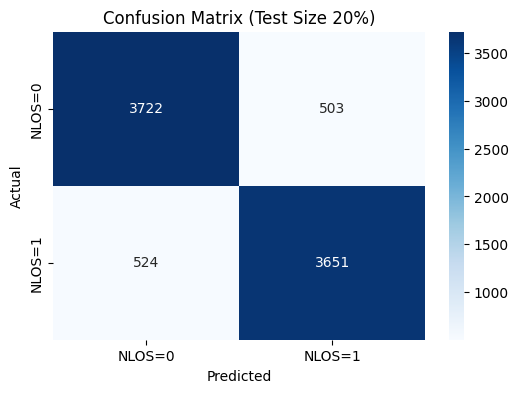


--- Split: Train 70%, Test 30% ---
Accuracy: 0.8752
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.87      0.87      6278
           1       0.88      0.88      0.88      6322

    accuracy                           0.88     12600
   macro avg       0.88      0.88      0.88     12600
weighted avg       0.88      0.88      0.88     12600

Confusion Matrix:
 [[5490  788]
 [ 785 5537]]


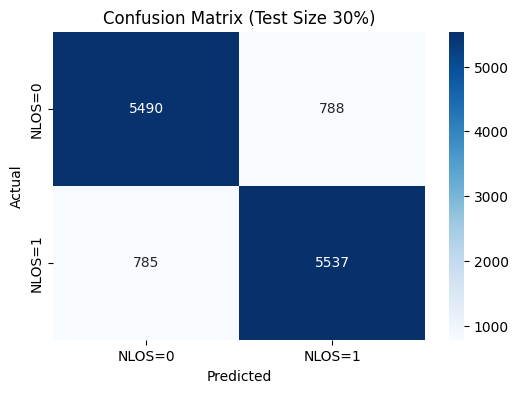


80:20 Split - Mean Accuracy: 0.8716, Std: 0.0028
70:30 Split - Mean Accuracy: 0.8700, Std: 0.0023

T-test results: t-statistic = 2.4337, p-value = 0.0180
There is a statistically significant difference between the splits.


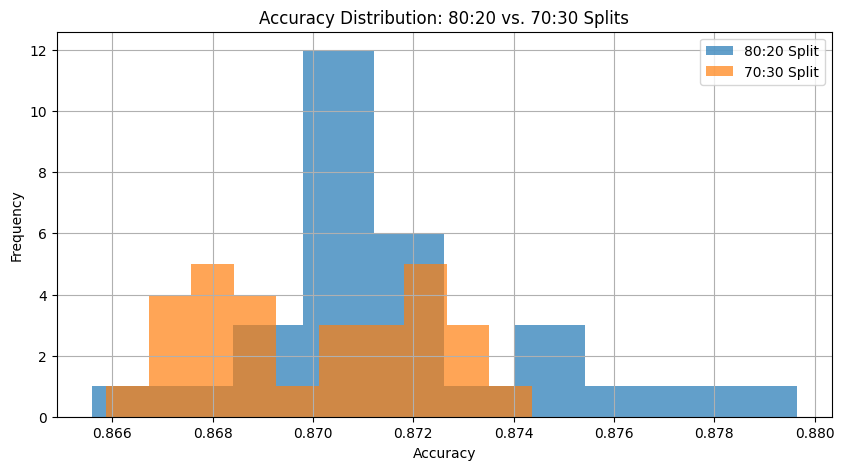


Conclusion: Based on repeated splits, the 80:20 split is recommended for further modeling.


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import scipy.stats as stats

# =============================================================================
# Part 1: Single Split Evaluation for 80:20 and 70:30
# =============================================================================

def evaluate_single_split(test_size, random_state=111):
    # Split data using the provided test_size
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    
    # Train Decision Tree Classifier
    clf = DecisionTreeClassifier(random_state=random_state)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"\n--- Split: Train {100 - int(test_size*100)}%, Test {int(test_size*100)}% ---")
    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:\n", report)
    print("Confusion Matrix:\n", cm)
    
    # Plot the confusion matrix for visual inspection
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=["NLOS=0", "NLOS=1"], yticklabels=["NLOS=0", "NLOS=1"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix (Test Size {int(test_size*100)}%)")
    plt.show()
    return accuracy

# Load the dataset from the prepared directory.
file_path = "../dataset/prepared/ClassifierPreparedDataset.csv"
df = pd.read_csv(file_path)

# Define features to drop (based on user's request)
# These were identified as lower-importance from the bar chart.
low_importance_features = [
    "FP_IDX", "FP_AMP2", "FRAME_LEN", "CH", "PREAM_LEN"
]

# Define features (X) and label (y)
# 'NLOS' is the target for classification.
features_to_drop = ["NLOS"] + low_importance_features
X = df.drop(columns=features_to_drop, errors="ignore")  # Keep 'RANGE' if you want it as a feature
y = df["NLOS"]

print("Single Split Evaluation:")

# Evaluate an 80:20 split.
acc_80 = evaluate_single_split(test_size=0.20, random_state=111)

# Evaluate a 70:30 split.
acc_70 = evaluate_single_split(test_size=0.30, random_state=111)

# =============================================================================
# Part 2: Repeated Splits Evaluation and Statistical Comparison
# =============================================================================

def evaluate_repeated_split(X, y, test_size, n_repeats=30, base_random_state=42):
    accuracies = []
    for i in range(n_repeats):
        rs = base_random_state + i
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=rs)
        clf = DecisionTreeClassifier(random_state=rs)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        accuracies.append(accuracy_score(y_test, y_pred))
    return np.array(accuracies)

# Evaluate for 80:20 split.
acc_80_20 = evaluate_repeated_split(X, y, test_size=0.20)
mean_acc_80 = np.mean(acc_80_20)
std_acc_80 = np.std(acc_80_20)
print("\n80:20 Split - Mean Accuracy: {:.4f}, Std: {:.4f}".format(mean_acc_80, std_acc_80))

# Evaluate for 70:30 split.
acc_70_30 = evaluate_repeated_split(X, y, test_size=0.30)
mean_acc_70 = np.mean(acc_70_30)
std_acc_70 = np.std(acc_70_30)
print("70:30 Split - Mean Accuracy: {:.4f}, Std: {:.4f}".format(mean_acc_70, std_acc_70))

# Conduct a t-test between the two splits.
t_stat, p_value = stats.ttest_ind(acc_80_20, acc_70_30)
print("\nT-test results: t-statistic = {:.4f}, p-value = {:.4f}".format(t_stat, p_value))
if p_value < 0.05:
    print("There is a statistically significant difference between the splits.")
else:
    print("No statistically significant difference between the splits.")

# Visualize the accuracy distributions.
plt.figure(figsize=(10, 5))
plt.hist(acc_80_20, bins=10, alpha=0.7, label="80:20 Split")
plt.hist(acc_70_30, bins=10, alpha=0.7, label="70:30 Split")
plt.xlabel("Accuracy")
plt.ylabel("Frequency")
plt.title("Accuracy Distribution: 80:20 vs. 70:30 Splits")
plt.legend()
plt.grid(True)
plt.show()

# Conclusion based on mean accuracies (if nearly identical, choose the one with larger test set)
if mean_acc_70 >= mean_acc_80:
    chosen_split = "70:30"
else:
    chosen_split = "80:20"
print(f"\nConclusion: Based on repeated splits, the {chosen_split} split is recommended for further modeling.")


KNN on ClassifierPreparedDataset [Chosen]:

Loaded DataFrame from ../dataset/prepared/ClassifierPreparedDataset.csv. Shape: (42000, 9)
Columns: ['NLOS', 'RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3', 'CIR_PWR', 'MAX_NOISE', 'RXPACC']

Training set: (29400, 3), Testing set: (12600, 3)

Single-split evaluation:
k = 1 => Training Accuracy: 1.0000, Test Accuracy: 0.7933
k = 5 => Training Accuracy: 0.8815, Test Accuracy: 0.8391
k = 6 => Training Accuracy: 0.8751, Test Accuracy: 0.8435
k = 7 => Training Accuracy: 0.8747, Test Accuracy: 0.8430
k = 8 => Training Accuracy: 0.8704, Test Accuracy: 0.8446
k = 10 => Training Accuracy: 0.8681, Test Accuracy: 0.8475
k = 15 => Training Accuracy: 0.8641, Test Accuracy: 0.8484
k = 20 => Training Accuracy: 0.8598, Test Accuracy: 0.8489
k = 25 => Training Accuracy: 0.8579, Test Accuracy: 0.8502
k = 30 => Training Accuracy: 0.8555, Test Accuracy: 0.8506


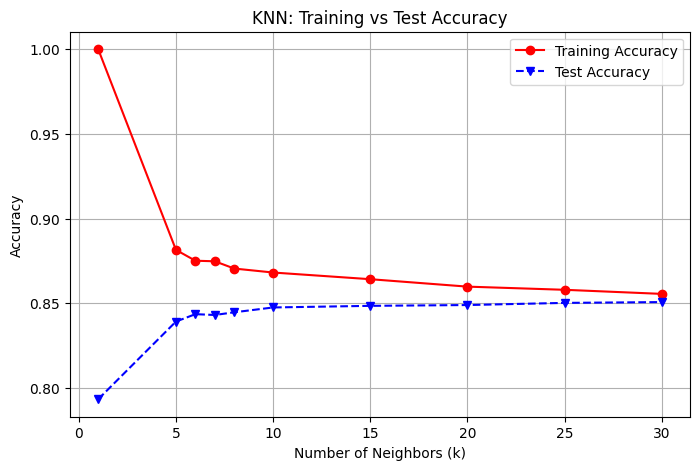


5-Fold Cross-Validation evaluation on training set:
k = 1 => CV Accuracy (on training set): 0.7971 (+/- 0.0050)
k = 5 => CV Accuracy (on training set): 0.8440 (+/- 0.0030)
k = 6 => CV Accuracy (on training set): 0.8491 (+/- 0.0015)
k = 7 => CV Accuracy (on training set): 0.8496 (+/- 0.0039)
k = 8 => CV Accuracy (on training set): 0.8503 (+/- 0.0030)
k = 10 => CV Accuracy (on training set): 0.8507 (+/- 0.0037)
k = 15 => CV Accuracy (on training set): 0.8525 (+/- 0.0028)
k = 20 => CV Accuracy (on training set): 0.8517 (+/- 0.0019)
k = 25 => CV Accuracy (on training set): 0.8505 (+/- 0.0033)
k = 30 => CV Accuracy (on training set): 0.8492 (+/- 0.0041)

Best k (based on training set CV): 15 with a 5-Fold CV Accuracy of: 0.8525


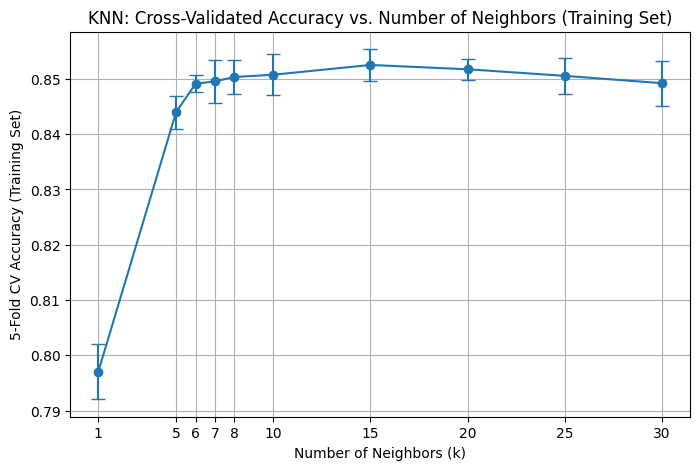


Final Test Accuracy with k = 10: 0.8475

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.81      0.91      0.86      6278
           1       0.90      0.78      0.84      6322

    accuracy                           0.85     12600
   macro avg       0.85      0.85      0.85     12600
weighted avg       0.85      0.85      0.85     12600



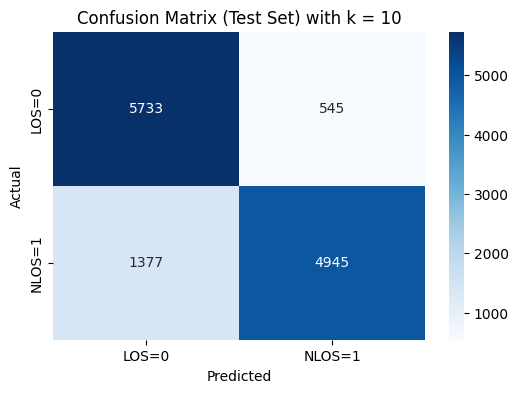

C:\Users\wmjia\AppData\Local\Temp\ipykernel_28056\581520914.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=perm_importances.values, y=perm_importances.index, palette="viridis")


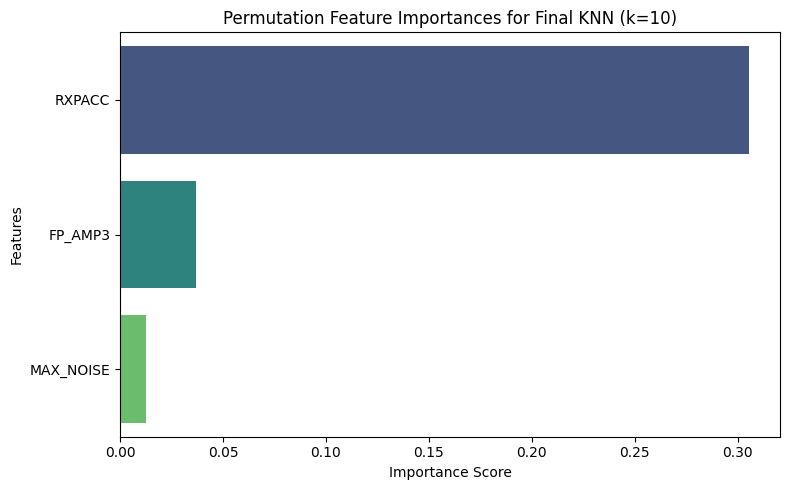

In [33]:
# =============================================================================
# Unified KNN Evaluation and Feature Importance for Classification
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix)
from sklearn.inspection import permutation_importance
import scipy.stats as stats

# -----------------------------
# Part 1: Data Loading and Preparation
# -----------------------------
file_path = "../dataset/prepared/ClassifierPreparedDataset.csv"
df = pd.read_csv(file_path)
print(f"Loaded DataFrame from {file_path}. Shape: {df.shape}")
print("Columns:", df.columns.tolist())

# Define features to drop (based on user's request)
# These were identified as lower-importance from the bar chart.
low_importance_features = [
    "FP_IDX", "RANGE", "FP_AMP1", "FP_AMP2", "CIR_PWR"
]

# Define features (X) and label (y)
# 'NLOS' is the target for classification.
features_to_drop = ["NLOS"] + low_importance_features
X = df.drop(columns=features_to_drop, errors="ignore")  # Keep 'RANGE' if you want it as a feature
y = df["NLOS"]


# Split the dataset into training (70%) and testing (30%) sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=111)
print(f"\nTraining set: {X_train.shape}, Testing set: {X_test.shape}")

# -----------------------------
# Part 2: Evaluate KNN with Single Train/Test Split for Different k Values
# -----------------------------
numNeighbors = [1, 5, 6, 7, 8, 10, 15, 20, 25, 30]
trainAcc = []
testAcc = []

print("\nSingle-split evaluation:")
for k in numNeighbors:
    clf1 = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2)
    clf1.fit(X_train, y_train)
    y_predTrain = clf1.predict(X_train)
    y_predTest = clf1.predict(X_test)
    acc_train = accuracy_score(y_train, y_predTrain)
    acc_test = accuracy_score(y_test, y_predTest)
    trainAcc.append(acc_train)
    testAcc.append(acc_test)
    print(f"k = {k} => Training Accuracy: {acc_train:.4f}, Test Accuracy: {acc_test:.4f}")

# Plot Training vs Test Accuracy for each k.
plt.figure(figsize=(8,5))
plt.plot(numNeighbors, trainAcc, 'ro-', label='Training Accuracy')
plt.plot(numNeighbors, testAcc, 'bv--', label='Test Accuracy')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('KNN: Training vs Test Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# Part 3: 5-Fold Cross-Validation on Training Set to Tune k
# -----------------------------
num_neighbors = [1, 5, 6, 7, 8, 10, 15, 20, 25, 30]
cv_mean_scores = []
cv_std_scores = []


print("\n5-Fold Cross-Validation evaluation on training set:")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for k in num_neighbors:
    knn = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2)  # Euclidean distance
    scores = cross_val_score(knn, X_train, y_train, cv=kf, scoring='accuracy')
    cv_mean_scores.append(scores.mean())
    cv_std_scores.append(scores.std())
    print(f"k = {k} => CV Accuracy (on training set): {scores.mean():.4f} (+/- {scores.std():.4f})")

# Identify best k based on CV mean accuracy.
best_index = np.argmax(cv_mean_scores)
best_k = num_neighbors[best_index]
best_accuracy = cv_mean_scores[best_index]
print(f"\nBest k (based on training set CV): {best_k} with a 5-Fold CV Accuracy of: {best_accuracy:.4f}")

# Plot the CV accuracies with error bars.
plt.figure(figsize=(8,5))
plt.errorbar(num_neighbors, cv_mean_scores, yerr=cv_std_scores, fmt='o-', capsize=5)
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('5-Fold CV Accuracy (Training Set)')
plt.title('KNN: Cross-Validated Accuracy vs. Number of Neighbors (Training Set)')
plt.xticks(num_neighbors)
plt.grid(True)
plt.show()

# -----------------------------
# Part 4: Final KNN Model Training and Evaluation on Test Set
# -----------------------------
# Here we use k=10 as an example; you may replace 10 with best_k from CV if desired.
final_k = 10
final_knn = KNeighborsClassifier(n_neighbors=final_k, metric='minkowski', p=2)
final_knn.fit(X_train, y_train)
y_pred = final_knn.predict(X_test)

final_accuracy = accuracy_score(y_test, y_pred)
print(f"\nFinal Test Accuracy with k = {final_k}: {final_accuracy:.4f}")
print("\nClassification Report on Test Set:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["LOS=0", "NLOS=1"], yticklabels=["LOS=0", "NLOS=1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix (Test Set) with k = {final_k}")
plt.show()

# -----------------------------
# Part 5: Permutation Importance for Final KNN Model
# -----------------------------
r = permutation_importance(final_knn, X_test, y_test, n_repeats=10, random_state=111)
perm_importances = pd.Series(r.importances_mean, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=perm_importances.values, y=perm_importances.index, palette="viridis")
plt.title("Permutation Feature Importances for Final KNN (k=" + str(final_k) + ")")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


Conclude the Split for KNN:


Loaded DataFrame from ../dataset/prepared/ClassifierPreparedDataset.csv. Shape: (42000, 9)
Columns: ['NLOS', 'RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3', 'CIR_PWR', 'MAX_NOISE', 'RXPACC']

KNN 80:20 Split - Mean Accuracy: 0.8506, Std: 0.0041
KNN 70:30 Split - Mean Accuracy: 0.8498, Std: 0.0028

KNN T-test results: t-statistic = 0.8501, p-value = 0.3988

Conclusion: Recommended split is 70:30 (no significant difference; larger test set for robust evaluation)


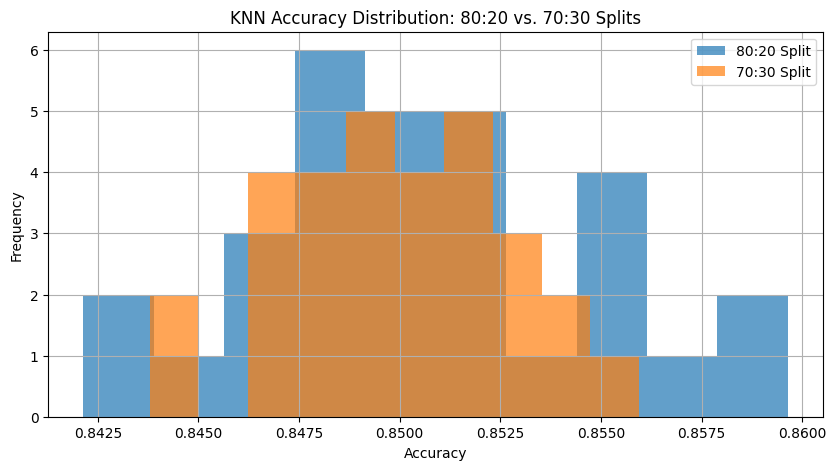


Final KNN Test Accuracy with k = 10: 0.8475

Final Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.91      0.86      6278
           1       0.90      0.78      0.84      6322

    accuracy                           0.85     12600
   macro avg       0.85      0.85      0.85     12600
weighted avg       0.85      0.85      0.85     12600



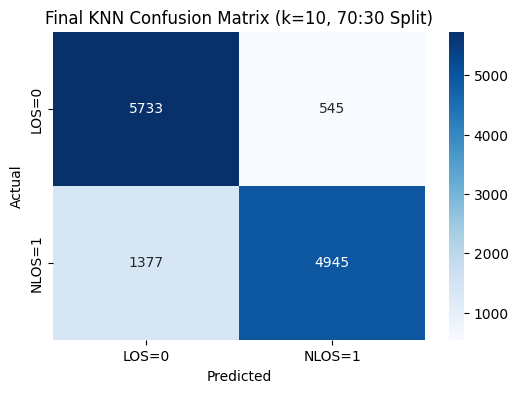

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import scipy.stats as stats

# =============================================================================
# Part 1: Data Loading and Preparation for KNN Evaluation
# =============================================================================

# Load the classification dataset from the prepared directory.
file_path = "../dataset/prepared/ClassifierPreparedDataset.csv"
df = pd.read_csv(file_path)
print(f"Loaded DataFrame from {file_path}. Shape: {df.shape}")
print("Columns:", df.columns.tolist())

# Define features to drop based on prior importance analysis.
# (Here we drop some features with low importance, e.g., FP_IDX, RANGE, FP_AMP1, FP_AMP2, CIR_PWR)
low_importance_features = ["FP_IDX", "RANGE", "FP_AMP1", "FP_AMP2", "CIR_PWR"]
features_to_drop = ["NLOS"] + low_importance_features
X = df.drop(columns=features_to_drop, errors="ignore")  # predictors
y = df["NLOS"]  # target for classification

# =============================================================================
# Part 3: Repeated Splits Evaluation and Statistical Comparison for KNN
# =============================================================================

def evaluate_repeated_split_KNN(X, y, test_size, n_repeats=30, base_random_state=42):
    accuracies = []
    for i in range(n_repeats):
        rs = base_random_state + i
        X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=test_size, random_state=rs)
        knn = KNeighborsClassifier(n_neighbors=10, metric='minkowski', p=2)  # using fixed k=10 for this comparison
        knn.fit(X_tr, y_tr)
        y_pred = knn.predict(X_te)
        accuracies.append(accuracy_score(y_te, y_pred))
    return np.array(accuracies)

# Evaluate for an 80:20 split.
acc_80_20 = evaluate_repeated_split_KNN(X, y, test_size=0.20)
mean_acc_80 = np.mean(acc_80_20)
std_acc_80 = np.std(acc_80_20)
print("\nKNN 80:20 Split - Mean Accuracy: {:.4f}, Std: {:.4f}".format(mean_acc_80, std_acc_80))

# Evaluate for a 70:30 split.
acc_70_30 = evaluate_repeated_split_KNN(X, y, test_size=0.30)
mean_acc_70 = np.mean(acc_70_30)
std_acc_70 = np.std(acc_70_30)
print("KNN 70:30 Split - Mean Accuracy: {:.4f}, Std: {:.4f}".format(mean_acc_70, std_acc_70))

# Conduct a t-test between the two splits.
t_stat, p_value = stats.ttest_ind(acc_80_20, acc_70_30)
print("\nKNN T-test results: t-statistic = {:.4f}, p-value = {:.4f}".format(t_stat, p_value))
if p_value < 0.05:
    if mean_acc_80 > mean_acc_70:
        recommended_split = "80:20 (more training data yields higher accuracy)"
    else:
        recommended_split = "70:30 (larger test set for robust evaluation)"
else:
    # When there is no significant difference, we opt for the split with a larger test set.
    recommended_split = "70:30 (no significant difference; larger test set for robust evaluation)"

print(f"\nConclusion: Recommended split is {recommended_split}")

# Plot histograms to compare the accuracy distributions.
plt.figure(figsize=(10, 5))
plt.hist(acc_80_20, bins=10, alpha=0.7, label="80:20 Split")
plt.hist(acc_70_30, bins=10, alpha=0.7, label="70:30 Split")
plt.xlabel("Accuracy")
plt.ylabel("Frequency")
plt.title("KNN Accuracy Distribution: 80:20 vs. 70:30 Splits")
plt.legend()
plt.grid(True)
plt.show()

# =============================================================================
# Part 4: Final KNN Model Training and Evaluation on Test Set
# =============================================================================

# Here we use k=10 (as determined from the single-split evaluation) or you may choose best_k from CV.
final_k = 10
final_knn = KNeighborsClassifier(n_neighbors=final_k, metric='minkowski', p=2)
# Use the 70:30 split recommended above.
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(X, y, test_size=0.30, random_state=111)
final_knn.fit(X_train_final, y_train_final)
y_pred_final = final_knn.predict(X_test_final)

final_accuracy = accuracy_score(y_test_final, y_pred_final)
print(f"\nFinal KNN Test Accuracy with k = {final_k}: {final_accuracy:.4f}")
print("\nFinal Classification Report:")
print(classification_report(y_test_final, y_pred_final))

cm = confusion_matrix(y_test_final, y_pred_final)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["LOS=0", "NLOS=1"], yticklabels=["LOS=0", "NLOS=1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Final KNN Confusion Matrix (k={final_k}, 70:30 Split)")
plt.show()


KNN on 8PCs dataset:

Loaded DataFrame from ../dataset/prepared/final_preprocessed_8PCs_both_all.csv. Shape: (42000, 19)
Columns: ['FP_IDX', 'FP_AMP1', 'FP_AMP2', 'CIR_PWR', 'MAX_NOISE', 'RXPACC', 'PREAM_LEN', 'STDEV_NOISE', 'FP_AMP3', 'CIR_PC1', 'CIR_PC2', 'CIR_PC3', 'CIR_PC4', 'CIR_PC5', 'CIR_PC6', 'CIR_PC7', 'CIR_PC8', 'NLOS', 'RANGE']

Training set: (29400, 8), Testing set: (12600, 8)

Single-split evaluation:
k = 1 => Training Accuracy: 1.0000, Test Accuracy: 0.7582
k = 5 => Training Accuracy: 0.8539, Test Accuracy: 0.7887
k = 6 => Training Accuracy: 0.8400, Test Accuracy: 0.7948
k = 7 => Training Accuracy: 0.8403, Test Accuracy: 0.7938
k = 8 => Training Accuracy: 0.8312, Test Accuracy: 0.7976
k = 10 => Training Accuracy: 0.8261, Test Accuracy: 0.7994
k = 15 => Training Accuracy: 0.8195, Test Accuracy: 0.7958
k = 20 => Training Accuracy: 0.8127, Test Accuracy: 0.7970
k = 25 => Training Accuracy: 0.8104, Test Accuracy: 0.7975
k = 30 => Training Accuracy: 0.8064, Test Accuracy: 0.7979


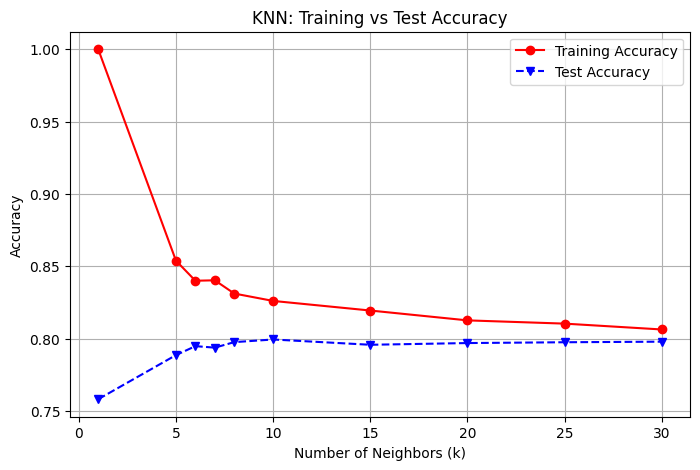


5-Fold Cross-Validation evaluation on training set:
k = 1 => CV Accuracy (on training set): 0.7524 (+/- 0.0087)
k = 5 => CV Accuracy (on training set): 0.7846 (+/- 0.0065)
k = 6 => CV Accuracy (on training set): 0.7925 (+/- 0.0090)
k = 7 => CV Accuracy (on training set): 0.7910 (+/- 0.0076)
k = 8 => CV Accuracy (on training set): 0.7945 (+/- 0.0073)
k = 10 => CV Accuracy (on training set): 0.7955 (+/- 0.0085)
k = 15 => CV Accuracy (on training set): 0.7931 (+/- 0.0068)
k = 20 => CV Accuracy (on training set): 0.7945 (+/- 0.0075)
k = 25 => CV Accuracy (on training set): 0.7933 (+/- 0.0072)
k = 30 => CV Accuracy (on training set): 0.7939 (+/- 0.0078)

Best k (based on training set CV): 10 with a 5-Fold CV Accuracy of: 0.7955


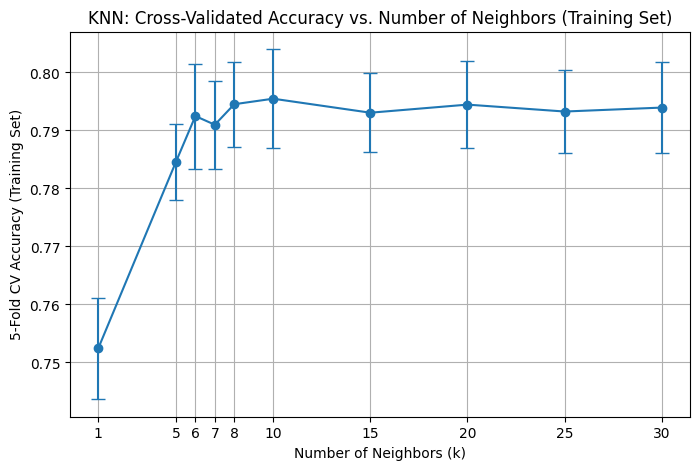


Final Test Accuracy with k = 10: 0.7994

Classification Report on Test Set:
              precision    recall  f1-score   support

         0.0       0.75      0.90      0.82      6278
         1.0       0.87      0.70      0.78      6322

    accuracy                           0.80     12600
   macro avg       0.81      0.80      0.80     12600
weighted avg       0.81      0.80      0.80     12600



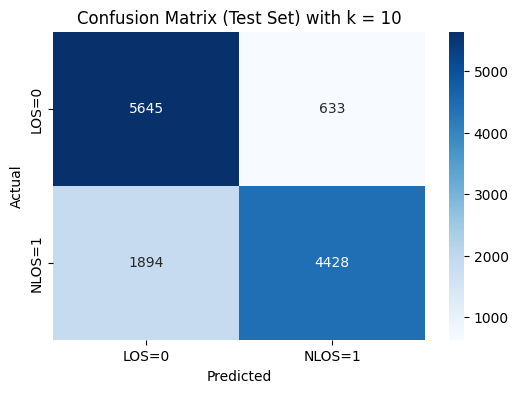

C:\Users\wmjia\AppData\Local\Temp\ipykernel_28056\4123107114.py:136: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=perm_importances.values, y=perm_importances.index, palette="viridis")


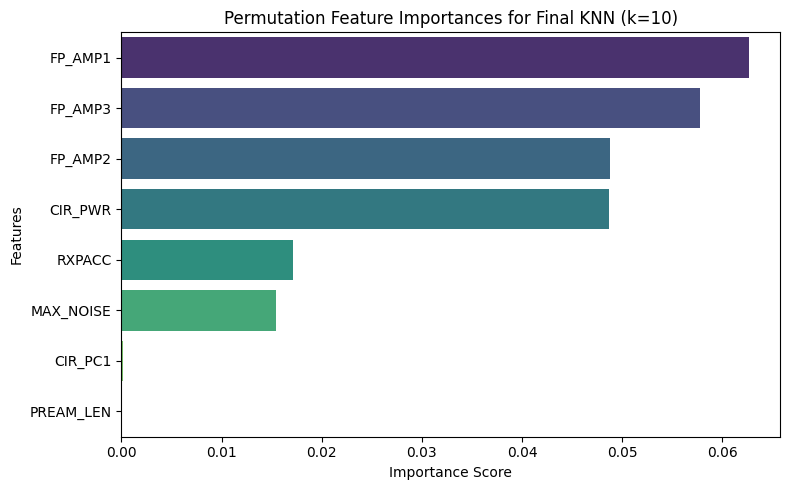

In [55]:
# =============================================================================
# Unified KNN Evaluation and Feature Importance for Classification
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix)
from sklearn.inspection import permutation_importance
import scipy.stats as stats

# -----------------------------
# Part 1: Data Loading and Preparation
# -----------------------------
file_path = "../dataset/prepared/final_preprocessed_8PCs_both_all.csv"
df = pd.read_csv(file_path)
print(f"Loaded DataFrame from {file_path}. Shape: {df.shape}")
print("Columns:", df.columns.tolist())

# Define features to drop (based on user's request)
# # These were identified as lower-importance from the bar chart.
low_importance_features = [
    "STDEV_NOISE", "CIR_PC4", "CIR_PC3", "CIR_PC8",
    "CIR_PC5", "CIR_PC6", "CIR_PC2", "CIR_PC7", "FP_IDX", "RANGE",
     
]

# Define features (X) and label (y)
# 'NLOS' is the target for classification.
features_to_drop = ["NLOS"] + low_importance_features
X = df.drop(columns=features_to_drop, errors="ignore")  # Keep 'RANGE' if you want it as a feature
y = df["NLOS"]


# Split the dataset into training (70%) and testing (30%) sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=111)
print(f"\nTraining set: {X_train.shape}, Testing set: {X_test.shape}")

# -----------------------------
# Part 2: Evaluate KNN with Single Train/Test Split for Different k Values
# -----------------------------
numNeighbors = [1, 5, 6, 7, 8, 10, 15, 20, 25, 30]
trainAcc = []
testAcc = []

print("\nSingle-split evaluation:")
for k in numNeighbors:
    clf1 = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2)
    clf1.fit(X_train, y_train)
    y_predTrain = clf1.predict(X_train)
    y_predTest = clf1.predict(X_test)
    acc_train = accuracy_score(y_train, y_predTrain)
    acc_test = accuracy_score(y_test, y_predTest)
    trainAcc.append(acc_train)
    testAcc.append(acc_test)
    print(f"k = {k} => Training Accuracy: {acc_train:.4f}, Test Accuracy: {acc_test:.4f}")

# Plot Training vs Test Accuracy for each k.
plt.figure(figsize=(8,5))
plt.plot(numNeighbors, trainAcc, 'ro-', label='Training Accuracy')
plt.plot(numNeighbors, testAcc, 'bv--', label='Test Accuracy')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('KNN: Training vs Test Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# Part 3: 5-Fold Cross-Validation on Training Set to Tune k
# -----------------------------
num_neighbors = [1, 5, 6, 7, 8, 10, 15, 20, 25, 30]
cv_mean_scores = []
cv_std_scores = []


print("\n5-Fold Cross-Validation evaluation on training set:")
# kf = KFold(n_splits=5, shuffle=True, random_state=42)
for k in num_neighbors:
    knn = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2)  # Euclidean distance
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    cv_mean_scores.append(scores.mean())
    cv_std_scores.append(scores.std())
    print(f"k = {k} => CV Accuracy (on training set): {scores.mean():.4f} (+/- {scores.std():.4f})")

# Identify best k based on CV mean accuracy.
best_index = np.argmax(cv_mean_scores)
best_k = num_neighbors[best_index]
best_accuracy = cv_mean_scores[best_index]
print(f"\nBest k (based on training set CV): {best_k} with a 5-Fold CV Accuracy of: {best_accuracy:.4f}")

# Plot the CV accuracies with error bars.
plt.figure(figsize=(8,5))
plt.errorbar(num_neighbors, cv_mean_scores, yerr=cv_std_scores, fmt='o-', capsize=5)
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('5-Fold CV Accuracy (Training Set)')
plt.title('KNN: Cross-Validated Accuracy vs. Number of Neighbors (Training Set)')
plt.xticks(num_neighbors)
plt.grid(True)
plt.show()

# -----------------------------
# Part 4: Final KNN Model Training and Evaluation on Test Set
# -----------------------------
# Here we use k=10 as an example; you may replace 10 with best_k from CV if desired.
final_k = 10
final_knn = KNeighborsClassifier(n_neighbors=final_k, metric='minkowski', p=2)
final_knn.fit(X_train, y_train)
y_pred = final_knn.predict(X_test)

final_accuracy = accuracy_score(y_test, y_pred)
print(f"\nFinal Test Accuracy with k = {final_k}: {final_accuracy:.4f}")
print("\nClassification Report on Test Set:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["LOS=0", "NLOS=1"], yticklabels=["LOS=0", "NLOS=1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix (Test Set) with k = {final_k}")
plt.show()

# -----------------------------
# Part 5: Permutation Importance for Final KNN Model
# -----------------------------
r = permutation_importance(final_knn, X_test, y_test, n_repeats=10, random_state=111)
perm_importances = pd.Series(r.importances_mean, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=perm_importances.values, y=perm_importances.index, palette="viridis")
plt.title("Permutation Feature Importances for Final KNN (k=" + str(final_k) + ")")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


Logistic Regression on ClassifierPreparedDataset:


Loaded DataFrame from ../dataset/prepared/ClassifierPreparedDataset.csv. Shape: (42000, 9)
Columns: ['NLOS', 'RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3', 'CIR_PWR', 'MAX_NOISE', 'RXPACC']

Training set: (29400, 4), Testing set: (12600, 4)

Logistic Regression Test Accuracy: 0.8581

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      6278
           1       0.90      0.81      0.85      6322

    accuracy                           0.86     12600
   macro avg       0.86      0.86      0.86     12600
weighted avg       0.86      0.86      0.86     12600

Confusion Matrix:
[[5716  562]
 [1226 5096]]


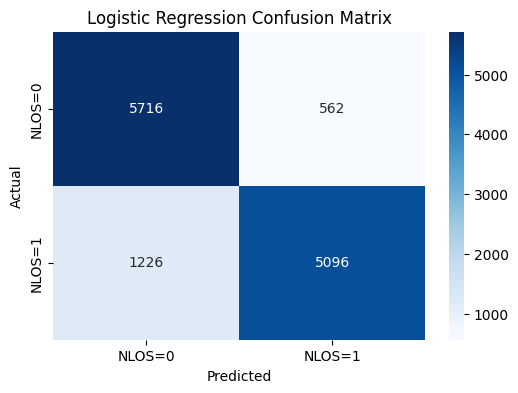

C:\Users\wmjia\AppData\Local\Temp\ipykernel_28056\1877241572.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=perm_importances.values, y=perm_importances.index, palette="viridis")


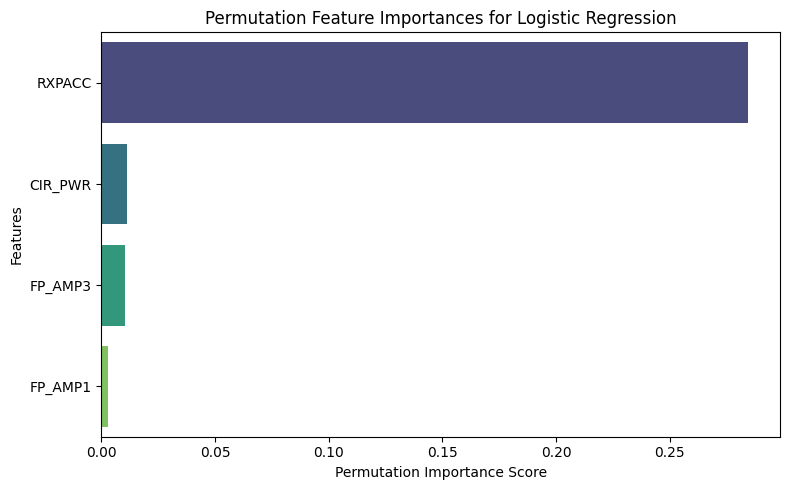


Logistic Regression Coefficients:
   Feature  Coefficient
3   RXPACC     0.006345
2  CIR_PWR    -0.000103
1  FP_AMP3    -0.000075
0  FP_AMP1    -0.000037


In [74]:
# =============================================================================
# Logistic Regression with Feature Importance: Unified Evaluation Cell
# =============================================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset from the prepared directory
file_path = "../dataset/prepared/ClassifierPreparedDataset.csv"
df = pd.read_csv(file_path)
print(f"Loaded DataFrame from {file_path}. Shape: {df.shape}")
print("Columns:", df.columns.tolist())

# Define features to drop (based on user's request)
# # These were identified as lower-importance from the bar chart.
low_importance_features = [
    "FP_IDX", "FP_AMP2", "MAX_NOISE", "RANGE"
     
]

# Define features (X) and label (y)
# 'NLOS' is the target for classification.
features_to_drop = ["NLOS"] + low_importance_features
X = df.drop(columns=features_to_drop, errors="ignore")  # Keep 'RANGE' if you want it as a feature
y = df["NLOS"]

# 3. Split the dataset into training (70%) and testing (30%) sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=111)
print(f"\nTraining set: {X_train.shape}, Testing set: {X_test.shape}")

# 4. Create and train the Logistic Regression model
logreg = LogisticRegression(random_state=111, max_iter=500)
logreg.fit(X_train, y_train)

# 5. Predict on the test set
y_pred_logreg = logreg.predict(X_test)

# 6. Evaluate the performance
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
print(f"\nLogistic Regression Test Accuracy: {accuracy_logreg:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_logreg))

# 7. Compute and display the confusion matrix
cm_logreg = confusion_matrix(y_test, y_pred_logreg)
print("Confusion Matrix:")
print(cm_logreg)

plt.figure(figsize=(6,4))
sns.heatmap(cm_logreg, annot=True, fmt="d", cmap="Blues",
            xticklabels=["NLOS=0", "NLOS=1"],
            yticklabels=["NLOS=0", "NLOS=1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# 8. Feature Importance using Permutation Importance
# Permutation importance measures the drop in accuracy when each feature is shuffled.
r = permutation_importance(logreg, X_test, y_test, n_repeats=10, random_state=111)
perm_importances = pd.Series(r.importances_mean, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=perm_importances.values, y=perm_importances.index, palette="viridis")
plt.xlabel("Permutation Importance Score")
plt.ylabel("Features")
plt.title("Permutation Feature Importances for Logistic Regression")
plt.tight_layout()
plt.show()

# Alternatively, you could also inspect the model coefficients:
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logreg.coef_[0]
}).sort_values(by="Coefficient", key=np.abs, ascending=False)
print("\nLogistic Regression Coefficients:")
print(coeff_df)


Validate the best split for LR:

Loaded DataFrame from ../dataset/prepared/ClassifierPreparedDataset.csv. Shape: (42000, 9)
Columns: ['NLOS', 'RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3', 'CIR_PWR', 'MAX_NOISE', 'RXPACC']

Single-split Logistic Regression Accuracy:
80:20 split: 0.8598
70:30 split: 0.8581

Repeated split evaluation (30 repeats):
80:20 split - Mean Accuracy: 0.8581, Std: 0.0037
70:30 split - Mean Accuracy: 0.8582, Std: 0.0027

T-test results: t-statistic = -0.0094, p-value = 0.9925
No statistically significant difference between the splits.


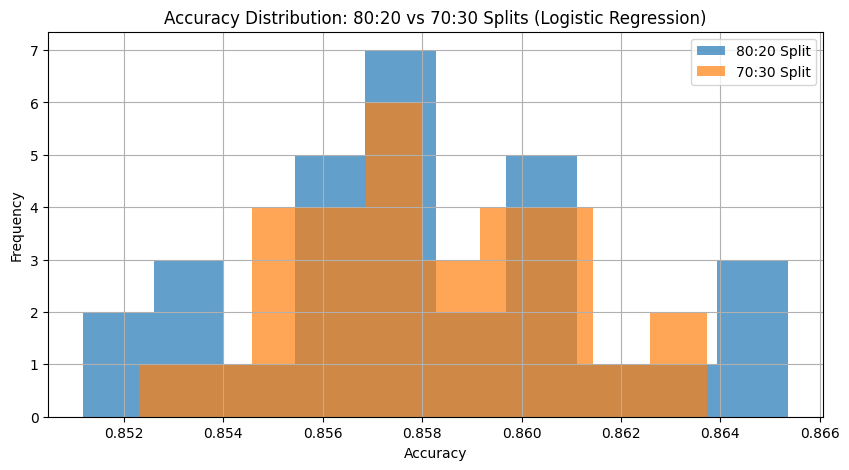


Conclusion: Based on repeated evaluation, the 70:30 split is recommended for further modeling.


In [75]:
# =============================================================================
# Logistic Regression: Evaluation of Different Train/Test Splits (80:20 vs 70:30)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import scipy.stats as stats

# 1. Load the dataset from the prepared directory
file_path = "../dataset/prepared/ClassifierPreparedDataset.csv"
df = pd.read_csv(file_path)
print(f"Loaded DataFrame from {file_path}. Shape: {df.shape}")
print("Columns:", df.columns.tolist())

# 2. Define features to drop (based on prior feature selection analysis)
#    We drop some lower-importance features.
low_importance_features = ["FP_IDX", "FP_AMP2", "MAX_NOISE", "RANGE"]
features_to_drop = ["NLOS"] + low_importance_features
X = df.drop(columns=features_to_drop, errors="ignore")
y = df["NLOS"]

# 3. Define a function to evaluate Logistic Regression on a given split.
def evaluate_logreg_split(test_size, random_state=111):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    logreg = LogisticRegression(random_state=random_state, max_iter=500)
    logreg.fit(X_train, y_train)
    y_pred = logreg.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return acc

# 4. Single-split evaluation:
acc_80 = evaluate_logreg_split(test_size=0.20, random_state=111)
acc_70 = evaluate_logreg_split(test_size=0.30, random_state=111)
print("\nSingle-split Logistic Regression Accuracy:")
print(f"80:20 split: {acc_80:.4f}")
print(f"70:30 split: {acc_70:.4f}")

# 5. Repeated evaluation: Function to perform n repeated random splits.
def repeated_eval(test_size, n_repeats=30, base_random_state=42):
    accuracies = []
    for i in range(n_repeats):
        rs = base_random_state + i
        acc = evaluate_logreg_split(test_size=test_size, random_state=rs)
        accuracies.append(acc)
    return np.array(accuracies)

accs_80 = repeated_eval(test_size=0.20)
accs_70 = repeated_eval(test_size=0.30)
mean_acc_80 = np.mean(accs_80)
mean_acc_70 = np.mean(accs_70)
std_acc_80 = np.std(accs_80)
std_acc_70 = np.std(accs_70)

print("\nRepeated split evaluation (30 repeats):")
print(f"80:20 split - Mean Accuracy: {mean_acc_80:.4f}, Std: {std_acc_80:.4f}")
print(f"70:30 split - Mean Accuracy: {mean_acc_70:.4f}, Std: {std_acc_70:.4f}")

# 6. Conduct a t-test to determine if the difference in accuracy is statistically significant.
t_stat, p_value = stats.ttest_ind(accs_80, accs_70)
print(f"\nT-test results: t-statistic = {t_stat:.4f}, p-value = {p_value:.4f}")
if p_value < 0.05:
    print("There is a statistically significant difference between the splits.")
else:
    print("No statistically significant difference between the splits.")

# 7. Visualize the accuracy distributions for both splits.
plt.figure(figsize=(10, 5))
plt.hist(accs_80, bins=10, alpha=0.7, label="80:20 Split")
plt.hist(accs_70, bins=10, alpha=0.7, label="70:30 Split")
plt.xlabel("Accuracy")
plt.ylabel("Frequency")
plt.title("Accuracy Distribution: 80:20 vs 70:30 Splits (Logistic Regression)")
plt.legend()
plt.grid(True)
plt.show()

# 8. Conclusion: Choose the split with a larger test set for robust evaluation if accuracies are similar.
# In our example, if the mean accuracy of the 80:20 split is higher and the p-value indicates significance,
# then we recommend the 80:20 split.
if mean_acc_80 > mean_acc_70:
    chosen_split = "80:20"
else:
    chosen_split = "70:30"
print(f"\nConclusion: Based on repeated evaluation, the {chosen_split} split is recommended for further modeling.")


LR on 8PCs dataset [Better]: 

Loaded DataFrame from ../dataset/prepared/final_preprocessed_8PCs_both_all.csv. Shape: (42000, 19)
Columns: ['FP_IDX', 'FP_AMP1', 'FP_AMP2', 'CIR_PWR', 'MAX_NOISE', 'RXPACC', 'PREAM_LEN', 'STDEV_NOISE', 'FP_AMP3', 'CIR_PC1', 'CIR_PC2', 'CIR_PC3', 'CIR_PC4', 'CIR_PC5', 'CIR_PC6', 'CIR_PC7', 'CIR_PC8', 'NLOS', 'RANGE']

Training set: (29400, 4), Testing set: (12600, 4)

Logistic Regression Test Accuracy: 0.8603

Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.88      0.86      6278
         1.0       0.88      0.84      0.86      6322

    accuracy                           0.86     12600
   macro avg       0.86      0.86      0.86     12600
weighted avg       0.86      0.86      0.86     12600

Confusion Matrix:
[[5552  726]
 [1034 5288]]


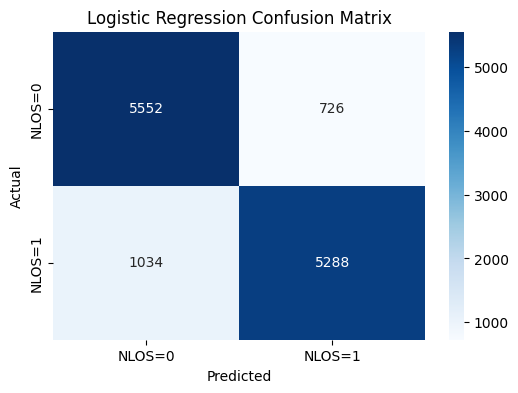

C:\Users\wmjia\AppData\Local\Temp\ipykernel_28056\2094355308.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=perm_importances.values, y=perm_importances.index, palette="viridis")


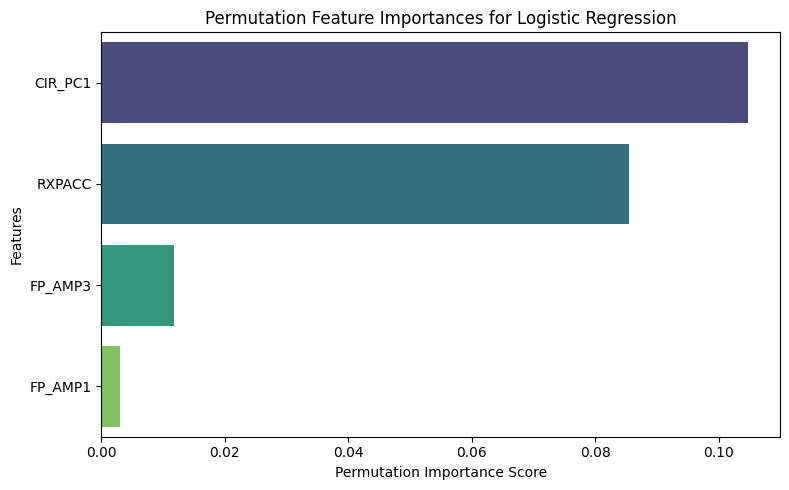


Logistic Regression Coefficients:
   Feature  Coefficient
3  CIR_PC1    -0.028918
1   RXPACC     0.003276
2  FP_AMP3    -0.000079
0  FP_AMP1    -0.000032


In [96]:
# =============================================================================
# Logistic Regression with Feature Importance: Unified Evaluation Cell
# =============================================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset from the prepared directory
file_path = "../dataset/prepared/final_preprocessed_8PCs_both_all.csv"
df = pd.read_csv(file_path)
print(f"Loaded DataFrame from {file_path}. Shape: {df.shape}")
print("Columns:", df.columns.tolist())

# Define features to drop (based on user's request)
# # These were identified as lower-importance from the bar chart.
low_importance_features = [
    "CIR_PC5", "RANGE", "CIR_PC6", "CIR_PC2", "CIR_PC8", "FP_IDX", "CIR_PC7", "PREAM_LEN",
    "CIR_PWR", "STDEV_NOISE", "FP_AMP2", "CIR_PC4", "CIR_PC3", "MAX_NOISE"
]

# Define features (X) and label (y)
# 'NLOS' is the target for classification.
features_to_drop = ["NLOS"] + low_importance_features
X = df.drop(columns=features_to_drop, errors="ignore")  # Keep 'RANGE' if you want it as a feature
y = df["NLOS"]

# 3. Split the dataset into training (70%) and testing (30%) sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=111)
print(f"\nTraining set: {X_train.shape}, Testing set: {X_test.shape}")

# 4. Create and train the Logistic Regression model
logreg = LogisticRegression(random_state=111, max_iter=500)
logreg.fit(X_train, y_train)

# 5. Predict on the test set
y_pred_logreg = logreg.predict(X_test)

# 6. Evaluate the performance
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
print(f"\nLogistic Regression Test Accuracy: {accuracy_logreg:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_logreg))

# 7. Compute and display the confusion matrix
cm_logreg = confusion_matrix(y_test, y_pred_logreg)
print("Confusion Matrix:")
print(cm_logreg)

plt.figure(figsize=(6,4))
sns.heatmap(cm_logreg, annot=True, fmt="d", cmap="Blues",
            xticklabels=["NLOS=0", "NLOS=1"],
            yticklabels=["NLOS=0", "NLOS=1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# 8. Feature Importance using Permutation Importance
# Permutation importance measures the drop in accuracy when each feature is shuffled.
r = permutation_importance(logreg, X_test, y_test, n_repeats=10, random_state=111)
perm_importances = pd.Series(r.importances_mean, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=perm_importances.values, y=perm_importances.index, palette="viridis")
plt.xlabel("Permutation Importance Score")
plt.ylabel("Features")
plt.title("Permutation Feature Importances for Logistic Regression")
plt.tight_layout()
plt.show()

# Alternatively, you could also inspect the model coefficients:
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logreg.coef_[0]
}).sort_values(by="Coefficient", key=np.abs, ascending=False)
print("\nLogistic Regression Coefficients:")
print(coeff_df)


Validate the split for CIR_PC dataset:

Loaded DataFrame from ../dataset/prepared/final_preprocessed_8PCs_both_all.csv. Shape: (42000, 19)
Columns: ['FP_IDX', 'FP_AMP1', 'FP_AMP2', 'CIR_PWR', 'MAX_NOISE', 'RXPACC', 'PREAM_LEN', 'STDEV_NOISE', 'FP_AMP3', 'CIR_PC1', 'CIR_PC2', 'CIR_PC3', 'CIR_PC4', 'CIR_PC5', 'CIR_PC6', 'CIR_PC7', 'CIR_PC8', 'NLOS', 'RANGE']

Single-split Logistic Regression Accuracy:
80:20 split: 0.8608
70:30 split: 0.8603

Repeated split evaluation (30 repeats):
80:20 split - Mean Accuracy: 0.8589, Std: 0.0035
70:30 split - Mean Accuracy: 0.8593, Std: 0.0027

T-test results: t-statistic = -0.4124, p-value = 0.6816
No statistically significant difference between the splits.


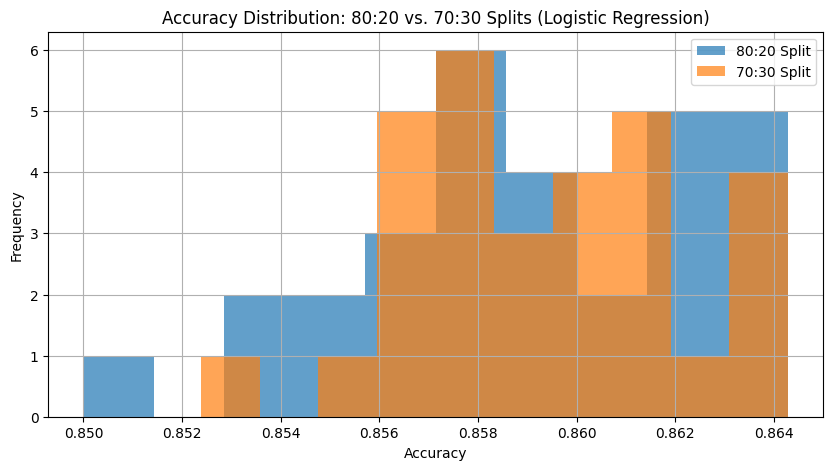


Conclusion: Based on repeated evaluation, the 70:30 split is recommended for further modeling.


In [97]:
# =============================================================================
# Logistic Regression Split Evaluation: 80:20 vs. 70:30
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import scipy.stats as stats

# 1. Load the dataset from the prepared directory
file_path = "../dataset/prepared/final_preprocessed_8PCs_both_all.csv"
df = pd.read_csv(file_path)
print(f"Loaded DataFrame from {file_path}. Shape: {df.shape}")
print("Columns:", df.columns.tolist())

# 2. Define features to drop (based on prior feature selection)
#    Here, we drop several low-importance features.
low_importance_features = ["CIR_PC5", "RANGE", "CIR_PC6", "CIR_PC2", "CIR_PC8",
                           "FP_IDX", "CIR_PC7", "PREAM_LEN", "CIR_PWR", 
                           "STDEV_NOISE", "FP_AMP2", "CIR_PC4", "CIR_PC3", "MAX_NOISE"]
features_to_drop = ["NLOS"] + low_importance_features
X = df.drop(columns=features_to_drop, errors="ignore")
y = df["NLOS"]

# 3. Define a function to evaluate Logistic Regression on a given split.
def evaluate_logreg_split(test_size, random_state=111):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    logreg = LogisticRegression(random_state=random_state, max_iter=500)
    logreg.fit(X_train, y_train)
    y_pred = logreg.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return acc

# 4. Single-split evaluation for 80:20 and 70:30 splits.
acc_80 = evaluate_logreg_split(test_size=0.20, random_state=111)
acc_70 = evaluate_logreg_split(test_size=0.30, random_state=111)
print("\nSingle-split Logistic Regression Accuracy:")
print(f"80:20 split: {acc_80:.4f}")
print(f"70:30 split: {acc_70:.4f}")

# 5. Repeated evaluation: Function to perform n repeated random splits.
def repeated_eval(test_size, n_repeats=30, base_random_state=42):
    accuracies = []
    for i in range(n_repeats):
        rs = base_random_state + i
        acc = evaluate_logreg_split(test_size=test_size, random_state=rs)
        accuracies.append(acc)
    return np.array(accuracies)

accs_80 = repeated_eval(test_size=0.20)
accs_70 = repeated_eval(test_size=0.30)
mean_acc_80 = np.mean(accs_80)
mean_acc_70 = np.mean(accs_70)
std_acc_80 = np.std(accs_80)
std_acc_70 = np.std(accs_70)

print("\nRepeated split evaluation (30 repeats):")
print(f"80:20 split - Mean Accuracy: {mean_acc_80:.4f}, Std: {std_acc_80:.4f}")
print(f"70:30 split - Mean Accuracy: {mean_acc_70:.4f}, Std: {std_acc_70:.4f}")

# 6. Perform a t-test to check for statistical significance between splits.
t_stat, p_value = stats.ttest_ind(accs_80, accs_70)
print(f"\nT-test results: t-statistic = {t_stat:.4f}, p-value = {p_value:.4f}")
if p_value < 0.05:
    print("There is a statistically significant difference between the splits.")
else:
    print("No statistically significant difference between the splits.")

# 7. Visualize the accuracy distributions.
plt.figure(figsize=(10, 5))
plt.hist(accs_80, bins=10, alpha=0.7, label="80:20 Split")
plt.hist(accs_70, bins=10, alpha=0.7, label="70:30 Split")
plt.xlabel("Accuracy")
plt.ylabel("Frequency")
plt.title("Accuracy Distribution: 80:20 vs. 70:30 Splits (Logistic Regression)")
plt.legend()
plt.grid(True)
plt.show()

# 8. Conclusion: Choose the split with a larger test set for robust evaluation if accuracies are similar.
# Here, if the mean accuracy is similar, we may choose the one with the larger test set.
if mean_acc_80 > mean_acc_70:
    chosen_split = "80:20"
else:
    chosen_split = "70:30"
print(f"\nConclusion: Based on repeated evaluation, the {chosen_split} split is recommended for further modeling.")
